In [1]:
%cd ..

/home/eli/jupyterlab/captcha-numpyro


# Poisson convolutional sparse coding — prior predictive

Step 4 of `notes/poisson-convsc-design.md`: check the generative geometry *before* spending
effort on inference. Nothing here is trained; every figure is a draw from the prior.

What is being verified:

1. **Placement, orientation, equivariance** — a spike at `(y, x)` lays the glyph down where it
   should, unflipped, and translating the count field translates the render.
2. **Counts modulate opacity and nothing else** — the composite stays on the straight line from
   background to ink colour.
3. **Prior-predictive draws** — the `poisson_hesc.py` figure-2 layout: count support, optical
   depth, opacity, composite mean, and an `obs` sample.
4. **Ink statistics vs. the real captchas.**

In [2]:
import glob

import hydra
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
from PIL import Image
import rootutils

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)

PosixPath('/home/eli/jupyterlab/captcha-numpyro')

In [3]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="prior"):
    cfg = hydra.compose(config_name="train.yaml",
                        overrides=["+experiment=poisson_convsc"])

model = hydra.utils.instantiate(cfg.model)
placements = model.keywords["placements"]
AMBIENT = model.keywords["ambient_depth"]
K, kh, kw, _ = placements.shape_dict.shapes.shape
H, W = placements.height, placements.width
labels = [placements.shape_dict.targets[i].split("_")[0] for i in range(K)]

def opacity_of(counts):
    """Optical depth and opacity, matching generate_poisson_convsc."""
    depth = placements.ink_field(jnp.asarray(counts))[..., 3:]
    return depth, -jnp.expm1(-(depth + AMBIENT))

print(f"{K} glyphs of {kh}x{kw} on a {H}x{W} canvas; "
      f"{H * W * K:,} Poisson sites per image; ambient_depth={AMBIENT}")

36 glyphs of 38x26 on a 80x80 canvas; 230,400 Poisson sites per image; ambient_depth=0.0001


## 1. Placement, orientation, equivariance

The strongest test of placement is to compare the *rendered patch* against the dictionary entry
itself — that checks position and orientation together, where a bounding-box centroid would
miss a flip.

Note the convention: a spike at `(y, x)` puts the glyph's `(kh, kw)` frame with its top-left
corner at `(y - (kh-1)//2, x - (kw-1)//2)`. For an even kernel dimension — 38 x 26 here — the
frame centre lands half a pixel past `(y, x)`, because a box with an even side has no centre
pixel. That is unavoidable, and irrelevant: equivariance is exact either way.

In [4]:
kernel = placements.ink_kernel
for (y, x, k) in [(40, 40, 7), (30, 63, 10), (55, 20, 35), (40, 40, 2)]:
    counts = jnp.zeros((1, H, W, K)).at[0, y, x, k].set(1.0)
    alpha = np.asarray(placements.ink_field(counts)[0, ..., 3])
    patch = alpha[y - (kh - 1) // 2:y - (kh - 1) // 2 + kh,
                  x - (kw - 1) // 2:x - (kw - 1) // 2 + kw]
    glyph = np.asarray(placements.shape_dict.shapes[k, ..., 3])
    print(f"spike (y={y:2d}, x={x:2d}, '{labels[k]}'):  "
          f"max|patch - glyph| = {np.abs(patch - glyph).max():.2e}   "
          f"vs 180-rotated = {np.abs(patch - glyph[::-1, ::-1]).max():.2e}")
print("\n(the residual is float32/TF32 convolution precision, not misplacement)")

spike (y=40, x=40, '7'):  max|patch - glyph| = 2.43e-04   vs 180-rotated = 1.00e+00
spike (y=30, x=63, 'A'):  max|patch - glyph| = 2.37e-04   vs 180-rotated = 1.00e+00
spike (y=55, x=20, 'Z'):  max|patch - glyph| = 2.22e-04   vs 180-rotated = 9.41e-01
spike (y=40, x=40, '2'):  max|patch - glyph| = 2.35e-04   vs 180-rotated = 1.00e+00

(the residual is float32/TF32 convolution precision, not misplacement)


In [5]:
rng = np.random.default_rng(0)
counts = jnp.asarray(rng.poisson(3.0 / (H * W * K), (1, H, W, K)).astype(np.float32))
for dy, dx in [(9, -13), (-4, 7)]:
    lhs = placements.ink_field(jnp.roll(counts, (dy, dx), axis=(1, 2)))
    rhs = jnp.roll(placements.ink_field(counts), (dy, dx), axis=(1, 2))
    inner = (slice(None), slice(25, H - 25), slice(25, W - 25))
    print(f"shift ({dy:+3d},{dx:+3d}):  max|stamp(L a) - L stamp(a)| = "
          f"{float(jnp.abs(lhs[inner] - rhs[inner]).max()):.3e}")

shift ( +9,-13):  max|stamp(L a) - L stamp(a)| = 0.000e+00
shift ( -4, +7):  max|stamp(L a) - L stamp(a)| = 0.000e+00


## 2. The count modulates opacity, and only opacity

Optical depth is `tau = sum_{k,y,x} a[k,y,x] * alpha_k(p - (y,x))`, opacity is
`A = 1 - exp(-(tau + ambient))`, and the composite is `A * fg + (1 - A) * bg`.

The composite's *hue* does shift along the row below — but that is alpha compositing over a
white background, not the count touching colour. The invariant that actually encodes
"opacity only" is that the pixel stays on the straight line from `bg` to `fg`: the ratio
`(mean - bg) / (fg - bg)` is a single scalar equal to `A`, identical in all three channels.

n= 1:  tau_max= 1.000  A_max=0.6322  per-channel ratio spread 0.00e+00
n= 2:  tau_max= 2.000  A_max=0.8647  per-channel ratio spread 1.79e-07
n= 3:  tau_max= 3.000  A_max=0.9502  per-channel ratio spread 1.19e-07
n= 5:  tau_max= 5.000  A_max=0.9933  per-channel ratio spread 5.96e-08
n=10:  tau_max=10.000  A_max=1.0000  per-channel ratio spread 1.79e-07


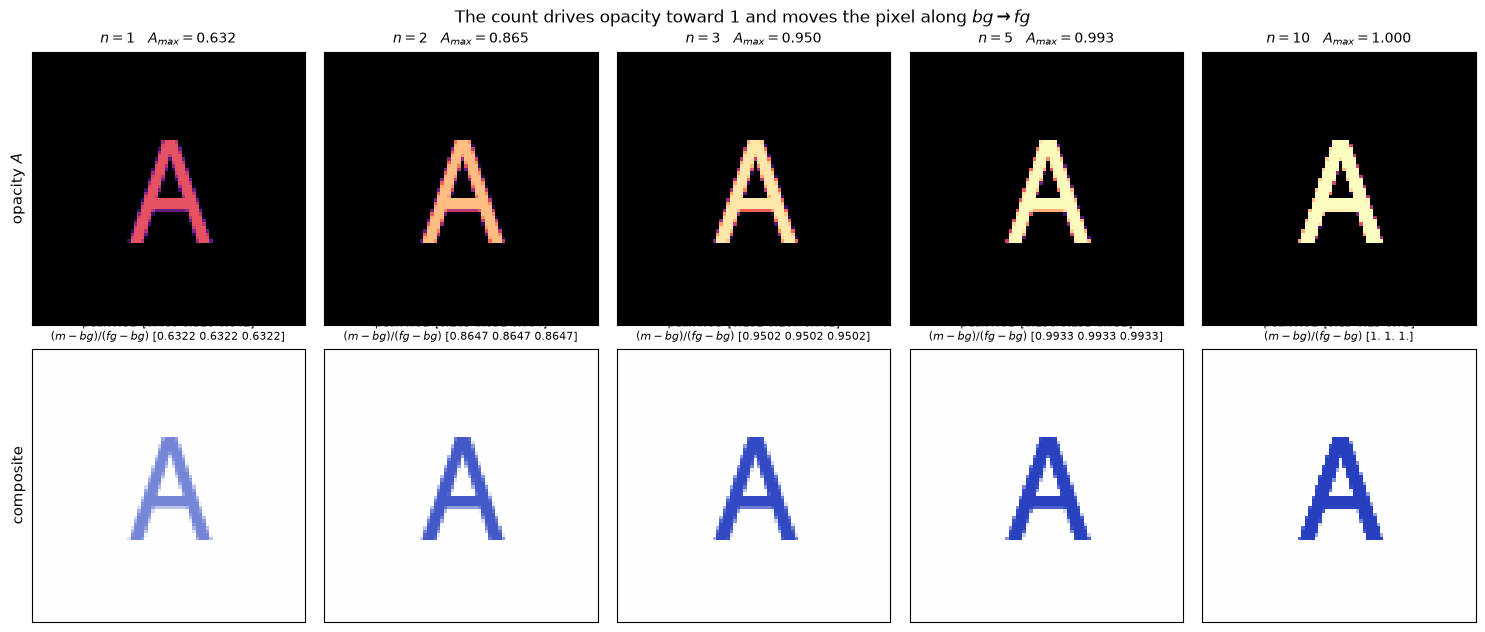

In [6]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6.4))
ink_color = jnp.array([0.15, 0.25, 0.75])
for col, n in enumerate([1, 2, 3, 5, 10]):
    counts = jnp.zeros((1, H, W, K)).at[0, H // 2, W // 2, 10].set(float(n))
    depth, A = opacity_of(counts)
    mean = A * ink_color + (1 - A) * jnp.ones(3)
    flat = np.asarray(A[0, ..., 0]).argmax()
    peak = np.asarray(mean[0])[flat // W, flat % W]
    ratio = (peak - 1.0) / (np.asarray(ink_color) - 1.0)

    ax[0, col].imshow(np.asarray(A[0, ..., 0]), cmap="magma", vmin=0, vmax=1)
    ax[0, col].set_title(f"$n={n}$   $A_{{max}}={float(A.max()):.3f}$", fontsize=10)
    ax[1, col].imshow(np.clip(np.asarray(mean[0]), 0, 1))
    ax[1, col].set_title(f"peak RGB {np.round(peak, 3)}\n"
                         f"$(m-bg)/(fg-bg)$ {np.round(ratio, 4)}", fontsize=8)
    print(f"n={n:2d}:  tau_max={float(depth.max()):6.3f}  A_max={float(A.max()):.4f}  "
          f"per-channel ratio spread {ratio.max() - ratio.min():.2e}")
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([])
ax[0, 0].set_ylabel("opacity $A$", fontsize=11)
ax[1, 0].set_ylabel("composite", fontsize=11)
fig.suptitle("The count drives opacity toward 1 and moves the pixel along $bg \\to fg$",
             fontsize=12)
fig.tight_layout()

### A single spike reaches 63% opacity, and that is the design working

A glyph's alpha peaks at 1.0, so one spike gives `tau_max = 1` and `A = 1 - e^-1 = 0.632`.
Driving opacity the rest of the way is exactly the job the count exists to do — the alpha is
amplified toward 1 by *more spikes*, not by a gain on the kernel. A learnable gain would
saturate opacity at `n = 1` and leave the count with nothing to modulate.

The question worth asking is whether the data needs more than one spike. It does, sometimes:

In [7]:
paths = sorted(glob.glob("data/captcha_sandbox/*.png"))[:400]
real = np.stack([np.asarray(Image.open(p).convert("RGB"), dtype=np.float32) / 255.
                 for p in paths])
darkest = real.mean(-1).reshape(len(real), -1).min(1)
print(f"per-image darkest pixel luminance: median {np.median(darkest):.3f}, "
      f"p5 {np.quantile(darkest, 0.05):.3f}, min {darkest.min():.3f}\n")
for n in (1, 2, 3):
    floor = np.exp(-n)   # darkest composite over white, with pure black ink
    print(f"  n={n}: opacity ceiling {1 - floor:.3f}, composite floor {floor:.3f}"
          f"  ->  {(darkest < floor).mean() * 100:5.1f}% of images have a pixel "
          f"unreachable at n={n}")

per-image darkest pixel luminance: median 0.404, p5 0.230, min 0.114

  n=1: opacity ceiling 0.632, composite floor 0.368  ->   40.8% of images have a pixel unreachable at n=1
  n=2: opacity ceiling 0.865, composite floor 0.135  ->    1.0% of images have a pixel unreachable at n=2
  n=3: opacity ceiling 0.950, composite floor 0.050  ->    0.0% of images have a pixel unreachable at n=3


So one spike covers ~59% of images, two cover 99%, three cover all of them. The count carries
real signal rather than collapsing to a presence indicator — which is also what keeps the
sparse-scatter route to deformable convolutions (§6 of the design note) affordable.

## 3. Prior-predictive draws

`expected_count = 1`, so a Poisson total of 0 happens about a third of the time; those draws are
skipped here rather than shown as blank rows.

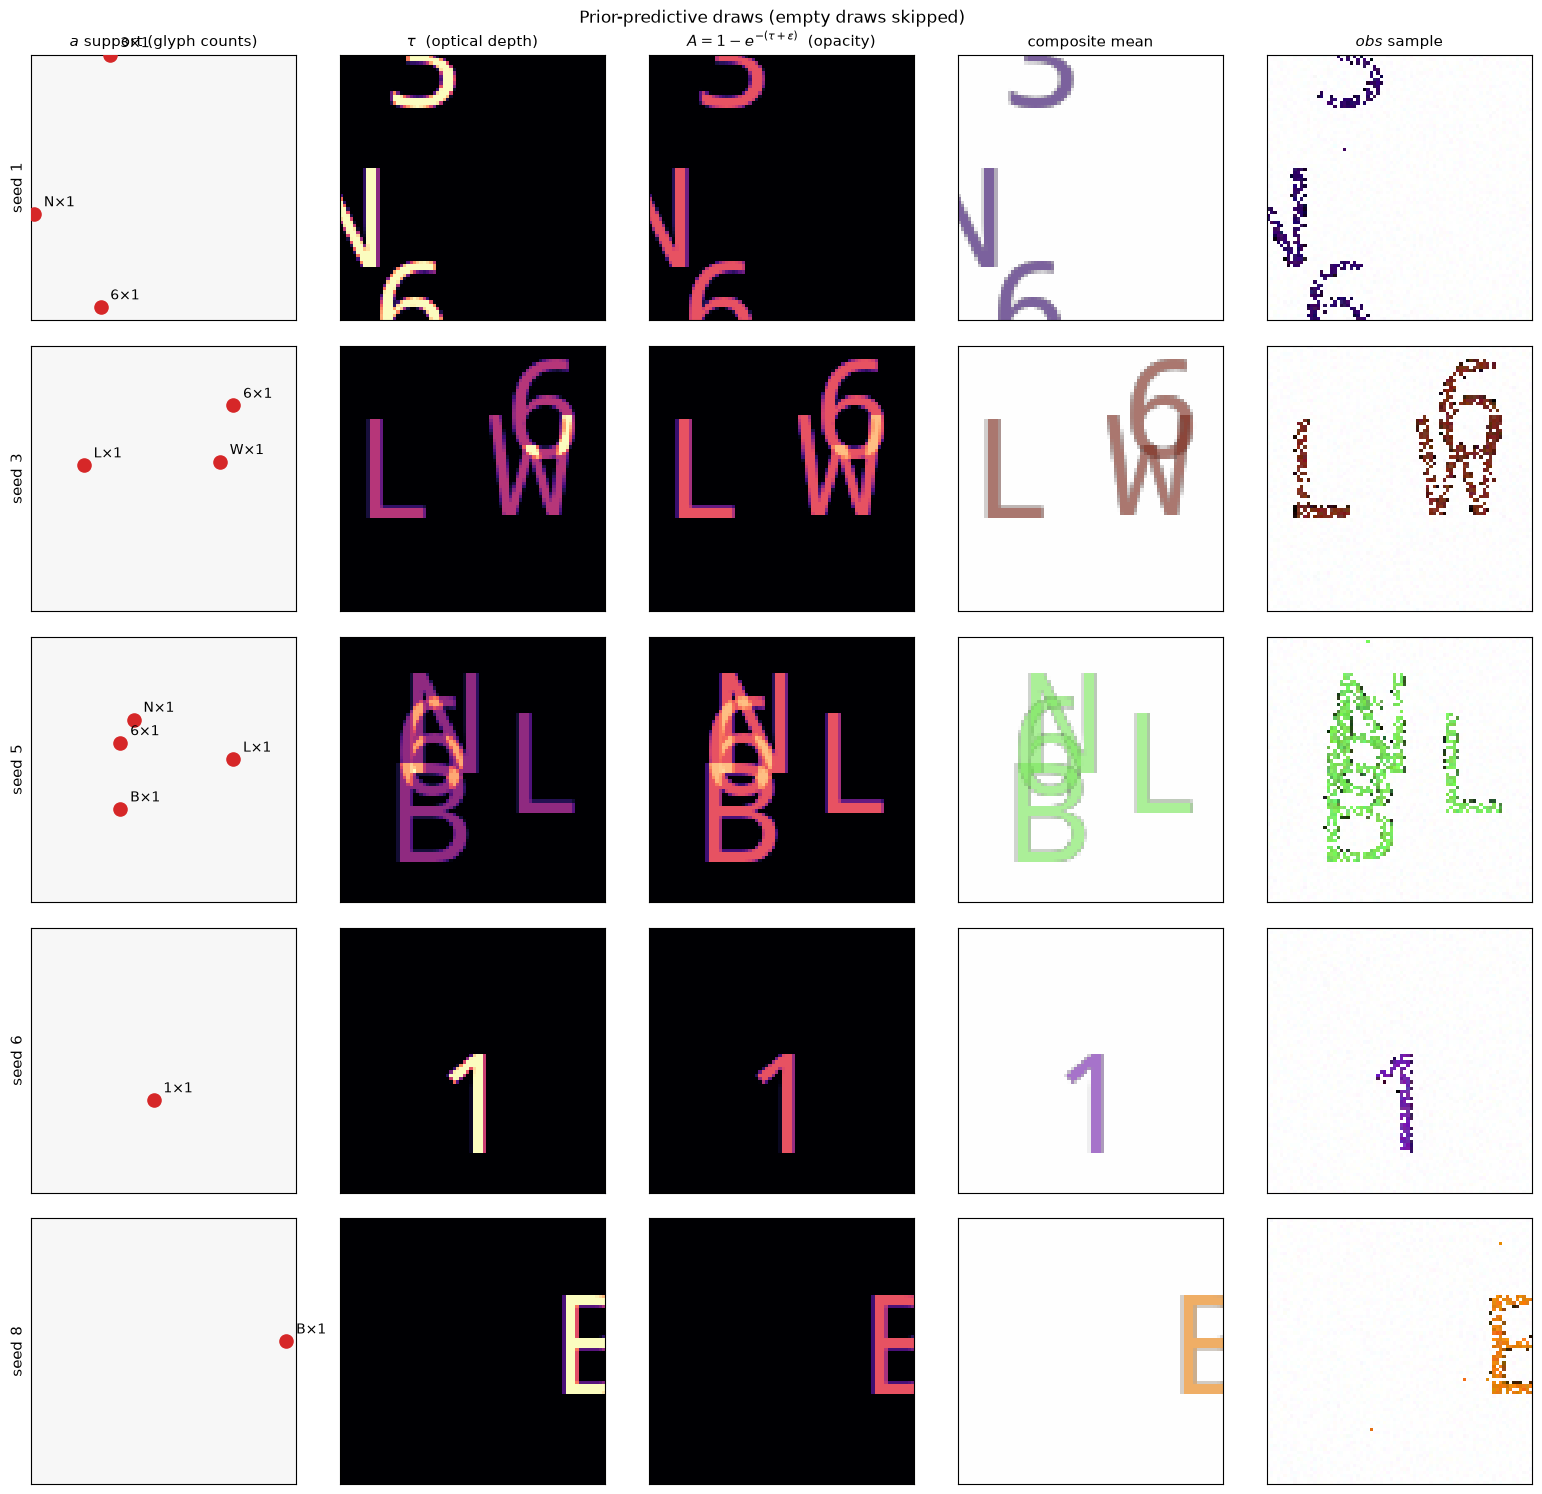

In [8]:
NS, row = 5, 0
fig, ax = plt.subplots(NS, 5, figsize=(15.5, 3.05 * NS))
cols = ["$a$ support (glyph counts)", "$\\tau$  (optical depth)",
        "$A = 1-e^{-(\\tau+\\epsilon)}$  (opacity)", "composite mean", "$obs$ sample"]
for seed in range(200):
    if row >= NS:
        break
    with numpyro.handlers.seed(rng_seed=seed):
        tr = numpyro.handlers.trace(model).get_trace(None, plot_mean=True)
    counts = np.asarray(tr["a"]["value"])
    if counts.sum() == 0:
        continue
    depth, A = opacity_of(counts)
    mean, obs = np.asarray(tr["mean"]["value"]), np.asarray(tr["obs"]["value"])

    ax[row, 0].set_facecolor("#f7f7f7")
    for (b, y, x, k) in zip(*np.nonzero(counts)):
        ax[row, 0].scatter(x, y, s=90 * counts[b, y, x, k], c="tab:red", zorder=3)
        ax[row, 0].annotate(f"{labels[k]}$\\times${counts[b, y, x, k]}", (x, y),
                            textcoords="offset points", xytext=(7, 5), fontsize=10)
    ax[row, 0].set_xlim(0, W); ax[row, 0].set_ylim(H, 0); ax[row, 0].set_aspect("equal")
    ax[row, 1].imshow(np.asarray(depth[0, ..., 0]), cmap="magma")
    ax[row, 2].imshow(np.asarray(A[0, ..., 0]), cmap="magma", vmin=0, vmax=1)
    ax[row, 3].imshow(np.clip(mean[0], 0, 1))
    ax[row, 4].imshow(np.clip(obs[0], 0, 1))
    ax[row, 0].set_ylabel(f"seed {seed}", fontsize=11)
    for c in range(5):
        ax[row, c].set_xticks([]); ax[row, c].set_yticks([])
        if row == 0:
            ax[row, c].set_title(cols[c], fontsize=11)
    row += 1
fig.suptitle("Prior-predictive draws (empty draws skipped)", fontsize=12)
fig.tight_layout()

Two things to read off these rows.

**Glyphs clipped by the frame render correctly.** That is the payoff of anchoring at image
resolution: the VALID anchor grid the earlier models used cannot place a character whose box
leaves the image.

**The `obs` column is heavily dithered, and the design note overstated this.** With two
components the per-pixel assignment is only near-deterministic once `A -> 1`; at the prior's
`n = 1` a glyph interior sits at `A = 0.632`, so 37% of its pixels are drawn from the background
component. Cutting from 37 components to 2 does not by itself make samples look like the render
— saturation does. This affects inspection only: the likelihood is exact, and `mean` is the
site to plot, which is why the model exposes it.

## 4. Ink statistics against the real captchas

  real captchas    ink pixels/image   296.8   intermediate 0.958   median luminance 0.501
  prior renders    ink pixels/image   414.7   intermediate 0.967   median luminance 0.709


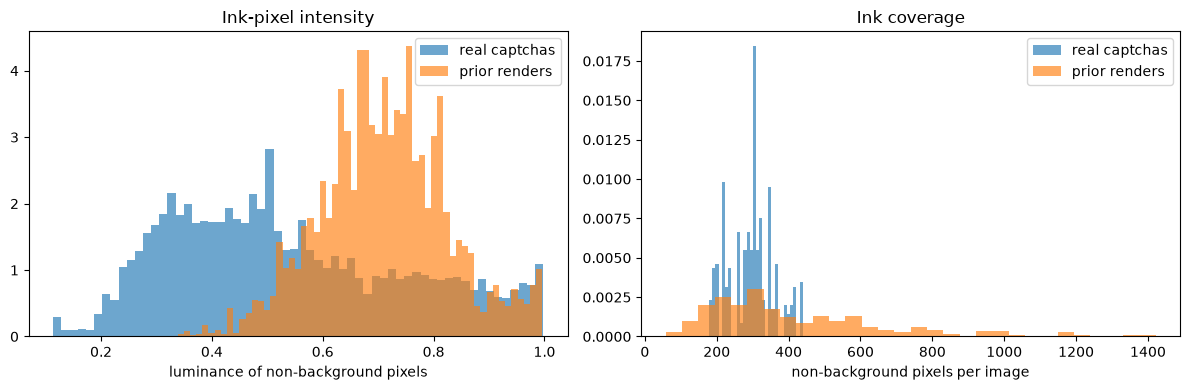

In [9]:
means = []
for seed in range(400):
    with numpyro.handlers.seed(rng_seed=1000 + seed):
        tr = numpyro.handlers.trace(model).get_trace(None, plot_mean=True)
    if np.asarray(tr["a"]["value"]).sum() > 0:
        means.append(np.asarray(tr["mean"]["value"])[0])
means = np.stack(means)

TOL = 1.0 / 255.0   # ambient_depth lifts EVERY pixel off exact white by ~1e-4,
                    # so an exact-white mask would call the whole canvas ink
def ink_stats(x, name):
    bg = np.abs(x - 1.0).max(-1) < TOL
    lum = x[~bg].mean(-1)
    print(f"  {name:16s} ink pixels/image {(~bg).sum() / len(x):7.1f}   "
          f"intermediate {(((lum > 0.05) & (lum < 0.95))).mean():.3f}   "
          f"median luminance {np.median(lum):.3f}")
    return lum, (~bg).reshape(len(x), -1).sum(1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
lr, cr = ink_stats(real, "real captchas")
lm, cm = ink_stats(means, "prior renders")
ax[0].hist(lr, bins=60, alpha=.65, density=True, label="real captchas")
ax[0].hist(lm, bins=60, alpha=.65, density=True, label="prior renders")
ax[0].set_xlabel("luminance of non-background pixels"); ax[0].legend()
ax[0].set_title("Ink-pixel intensity")
ax[1].hist(cr, bins=30, alpha=.65, density=True, label="real captchas")
ax[1].hist(cm, bins=30, alpha=.65, density=True, label="prior renders")
ax[1].set_xlabel("non-background pixels per image"); ax[1].legend()
ax[1].set_title("Ink coverage")
fig.tight_layout()

Coverage is in the right range (a glyph's alpha support is ~235 pixels against the data's ~297,
and prior draws with two glyphs overshoot). The renders are *lighter* than the data — median
ink luminance around 0.71 against 0.50 — and that is mostly the colour prior, not the opacity
ceiling: `Beta(1,1)^3` has mean luminance 0.5 and real captcha ink is darker than mid-grey.

One structural note for inference. Reaching `n >= 2` at a *single* site requires the factorized
prior to co-locate spikes, which at a rate of `4.3e-6` per site it essentially never does. So
prior-predictive draws will always be single-stamp and faint; it is the *posterior* that has to
co-locate, at a KL cost of roughly 25-40 nats against a likelihood of order `1e4`. Cheap, but
worth knowing where the pressure has to come from — and a reason the `expected_count`
initialiser may want to be 2 rather than 1.